In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sunil123kumar/netflix-movies-and-tv-shows-dataset/netflix_titles.csv


# Netflix Data Analysis 🎬
**Tools:** Python, Pandas, Matplotlib  
**Dataset:** Netflix Movies and TV Shows Dataset

## What I did
- Loaded and explored dataset
- Cleaned missing values
- Answered 3 questions about data
- Visualize findings with charts

In [25]:
# Loading Data
df = pd.read_csv('/kaggle/input/datasets/sunil123kumar/netflix-movies-and-tv-shows-dataset/netflix_titles.csv')


In [41]:
# Exploring Data
df.head()
df.shape
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water          Unknown   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans          Unknown   
4         s5  TV Show           Kota Factory          Unknown   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb          Unknown   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                               Unknown  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [28]:
# Checking missing data
df.isnull().sum()
df.isnull().sum() / len(df)*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [36]:
# Cleaning data
df.fillna("Unknown", inplace = True)

In [30]:
# Verifying
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [35]:
# Saving cleaned file
df.to_csv('NetflixMovieDataset_cleaned.csv', index = False)

In [37]:
# What's the split between Movies and TV Shows
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [40]:
# Which country produces the most content
df['country'].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [42]:
# Which year has the most releases
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

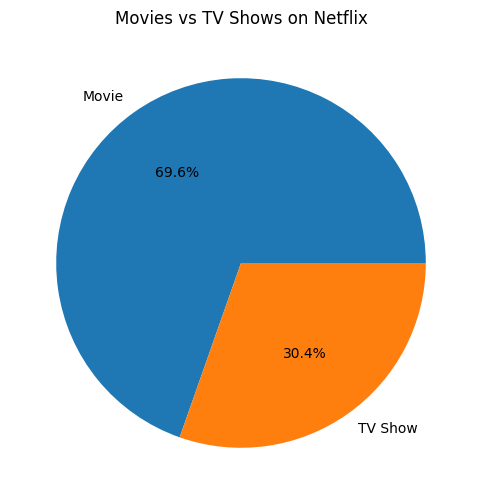

In [48]:
# Movies vs TV Shows
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%', figsize = (6,6))
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()

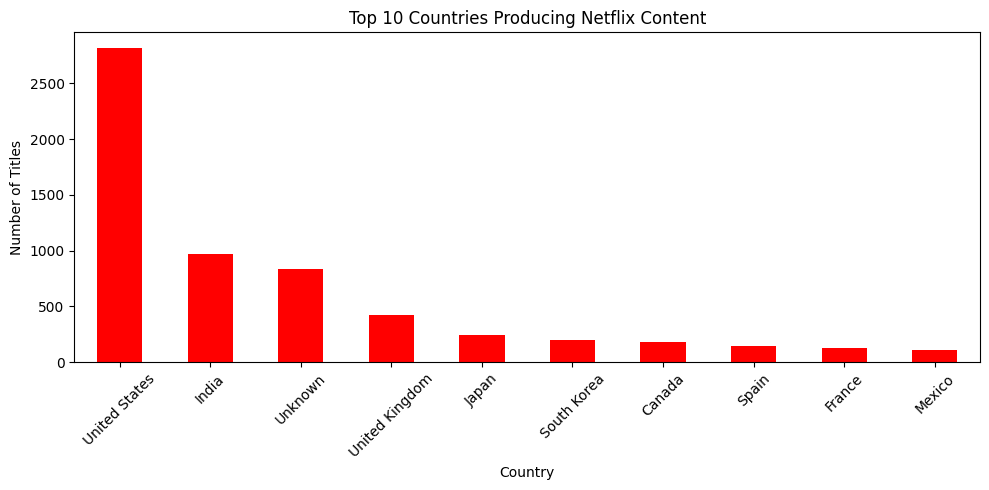

In [53]:
df['country'].value_counts().head(10).plot(kind ='bar', figsize = (10,5), color = 'red')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation =45)
plt.tight_layout()
plt.show()

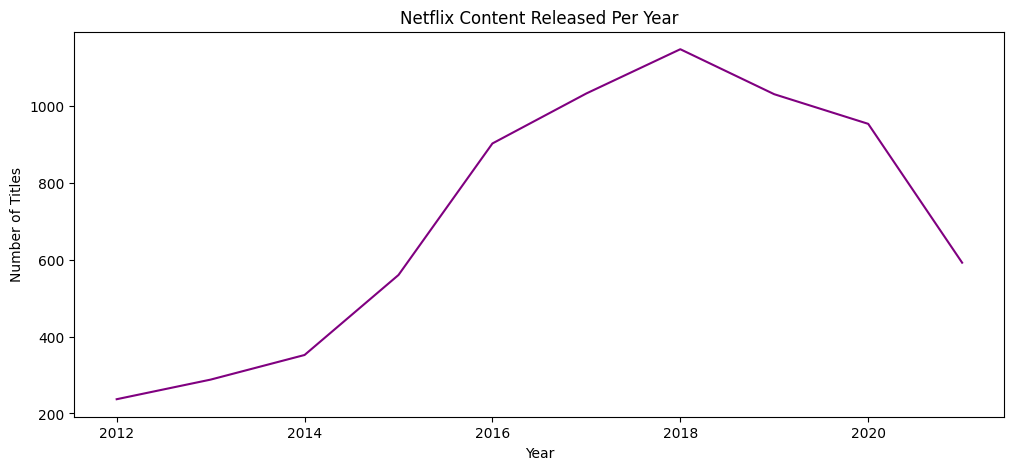

In [55]:
df['release_year'].value_counts().head(10).sort_index().plot(kind = 'line', figsize = (12,5), color = 'purple')
plt.title('Netflix Content Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()